# Demo: program VMMC vs. non-program traditional male circumcision.

## Four scenarios

1. baseline      - no circumcision of any kind.
2. program VMMC  - ~1000 circumcisions/year targeted at uncircumcised men
                   aged 25+ (eff_circ, HIV default = 0.6).
3. traditional   - 10% of pre-sexual-debut boys are traditionally
                   circumcised at age 15 (eff_circ_traditional = 0.5, less
                   protective than the program's medical procedure).
4. combined      - both (2) and (3) running together.

Coverage note: VMMC's `coverage` is a *stock* (prevalence) target, not a
flow — see the comment in `VMMC.step()`. To approximate "~1000 new
circumcisions per year" we ramp a cumulative `n_vmmc` target by 1000/year;
once that target exceeds the eligible pool, uptake naturally saturates (you
can see this in the program-VMMC panel of the plot below).


In [32]:
import numpy as np
import matplotlib.pyplot as plt
import starsim as ss
import stisim as sti

n_agents = 10000
start = 2000
dur = 25  # years
eligible_age = 25       # program VMMC target population: men 25+
traditional_age = 15    # traditional circumcision assessed at this age
traditional_prob = 0.1  # 10% of pre-debut boys get traditional circumcision
eff_circ_traditional = 0.5  # less protective than program VMMC (default eff_circ=0.6)


class CircumcisionTracker(ss.Analyzer):
    """
    Records alive-male population and circumcision-by-type counts EVERY STEP.

    Both quantities change over time (births/deaths grow and shrink the
    population; `HIV.step_die()` resets `circumcised`/`circ_traditional` to
    False when someone dies, matching how `on_art`/`diagnosed` are
    cleared on death). That means neither can be recovered correctly from a
    single post-run snapshot:
      - `people.male.raw` at the end of the run includes preallocated
        capacity for not-yet-born agents, so a single final count wildly
        overstates the population at any earlier point in the sim.
      - Reconstructing "who was circumcised when" from the final
        `ti_circumcised` snapshot silently drops anyone circumcised early who
        has since died -- and early cohorts have had more time to die than
        recent ones, which biases the reconstructed curve to look like
        uptake ramped up gradually even when (as here) it was actually
        immediate. Recording the counts live, as the sim progresses, avoids
        both problems.
    """
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.name = 'circ_track'
        return

    def init_results(self):
        super().init_results()
        self.define_results(
            ss.Result('n_alive_male', dtype=int, auto_plot=False),
            ss.Result('n_circ_program', dtype=int, auto_plot=False),
            ss.Result('n_circ_traditional', dtype=int, auto_plot=False),
        )
        return

    def step(self):
        ti = self.ti
        ppl = self.sim.people
        hiv = self.sim.diseases.hiv
        self.results.n_alive_male[ti] = (ppl.male & ppl.alive).count()
        self.results.n_circ_program[ti] = (hiv.circumcised & ~hiv.circ_traditional).count()
        self.results.n_circ_traditional[ti] = (hiv.circumcised & hiv.circ_traditional).count()
        return


def make_sim(vmmc, label):
    """A fresh HIV+VMMC sim; only `vmmc` (and, via it, HIV's eff_circ_traditional) varies."""
    hiv = sti.HIV(beta_m2f=0.05, beta_m2c=0.1, init_prev=0.05,
                  eff_circ_traditional=eff_circ_traditional)
    sim = sti.Sim(
        start=start, dur=dur, n_agents=n_agents,
        diseases=[hiv],
        networks=[sti.StructuredSexual(recall_prior=True), sti.PriorPartners()],
        demographics=[ss.Pregnancy(fertility_rate=10), ss.Deaths(death_rate=10)],
        interventions=[vmmc] if vmmc is not None else [],
        analyzers=[CircumcisionTracker()],
    )
    sim.label = label
    return sim

In [28]:
years = np.arange(start, start + dur + 1)
# Cumulative stock target that grows by ~100/year (see coverage note above)
n_vmmc_cumulative = {'year': years, 'value': 100 * (years - start), 'format': 'n'}

program_eligibility = lambda sim: sim.people.age >= eligible_age  # noqa: E731

#program_coverage = 0.25

scenarios = [
    make_sim(None, 'baseline'),
    make_sim(sti.VMMC(coverage=n_vmmc_cumulative, eligibility=program_eligibility),
    #make_sim(sti.VMMC(coverage=program_coverage, eligibility=program_eligibility),
             'program VMMC'),
    make_sim(sti.VMMC(traditional_prob=traditional_prob, traditional_age=traditional_age),
              'traditional MC'),
    #make_sim(sti.VMMC(coverage=program_coverage, eligibility=program_eligibility,
    make_sim(sti.VMMC(coverage=n_vmmc_cumulative, eligibility=program_eligibility,
                       traditional_prob=traditional_prob, traditional_age=traditional_age),
              'program + traditional'),
]

for sim in scenarios:
    sim.run(verbose=0)


Initializing sim "baseline" with 10000 agents
Initializing sim "program VMMC" with 10000 agents
Initializing sim "traditional MC" with 10000 agents
Initializing sim "program + traditional" with 10000 agents


In [29]:
# --------------------------------------------------------------------------
# Summary
# --------------------------------------------------------------------------
print(f'{"scenario":24s}  {"cum. male infections":>22s}  {"n circ (program)":>17s}  {"n circ (traditional)":>21s}')
for sim in scenarios:
    hiv = sim.diseases.hiv
    male_infections = int(sum(hiv.results.new_infections_m))
    n_program = int(np.count_nonzero(hiv.circumcised & (hiv.circ_type == 1)))
    n_traditional = int(np.count_nonzero(hiv.circumcised & (hiv.circ_type == 2)))
    print(f'{sim.label:24s}  {male_infections:22d}  {n_program:17d}  {n_traditional:21d}')

scenario                    cum. male infections   n circ (program)   n circ (traditional)
baseline                                     980                  0                      0
program VMMC                                 940                806                      0
traditional MC                               963                  0                    141
program + traditional                        933                682                    140


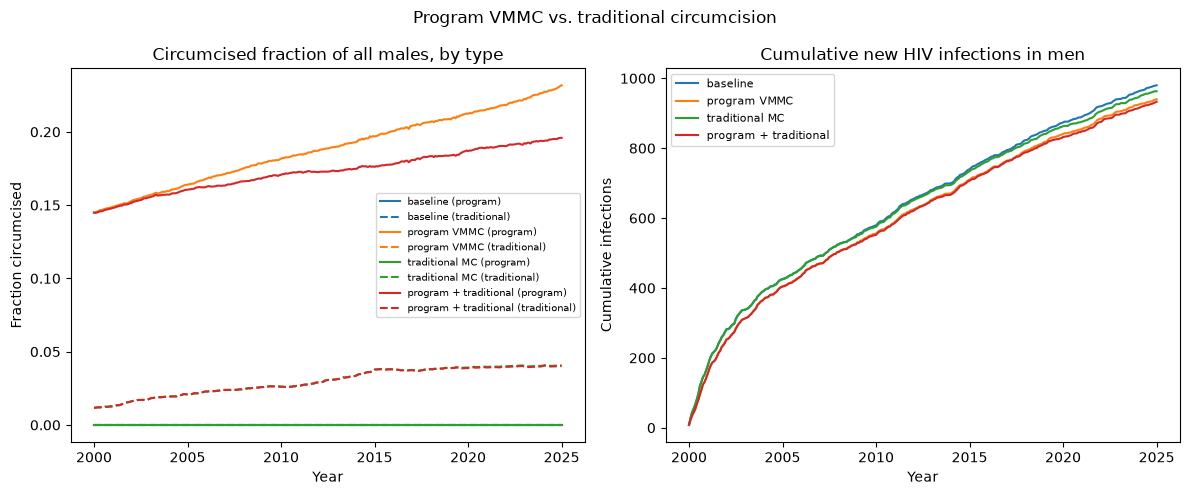

In [30]:
# --------------------------------------------------------------------------
# Plot: circumcision uptake by type, and cumulative male infections, over time
# --------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = dict(zip([s.label for s in scenarios], plt.cm.tab10.colors))

ax = axes[0]
for sim in scenarios:
    track = sim.results.circ_track
    timevec = track.timevec
    # Both numerator and denominator are live per-step counts (see
    # CircumcisionTracker) -- no post-hoc reconstruction, so no survivorship bias.
    n_alive_male = np.maximum(np.asarray(track.n_alive_male), 1)
    frac_program = np.asarray(track.n_circ_program) / n_alive_male
    frac_traditional = np.asarray(track.n_circ_traditional) / n_alive_male
    ax.plot(timevec, frac_program, color=colors[sim.label], linestyle='-', label=f'{sim.label} (program)')
    ax.plot(timevec, frac_traditional, color=colors[sim.label], linestyle='--', label=f'{sim.label} (traditional)')
ax.set_title('Circumcised fraction of all males, by type')
ax.set_xlabel('Year')
ax.set_ylabel('Fraction circumcised')
ax.legend(fontsize=7)


ax = axes[1]
for sim in scenarios:
    hiv = sim.diseases.hiv
    timevec = hiv.results.timevec
    cum_inf = np.cumsum(hiv.results.new_infections_m)
    ax.plot(timevec, cum_inf, color=colors[sim.label], label=sim.label)
ax.set_title('Cumulative new HIV infections in men')
ax.set_xlabel('Year')
ax.set_ylabel('Cumulative infections')
ax.legend(fontsize=8)

fig.suptitle('Program VMMC vs. traditional circumcision')
fig.tight_layout()
#plt.savefig('vmmc_traditional_circumcision_demo.png', dpi=150)
#print('Saved figure to vmmc_traditional_circumcision_demo.png')
plt.show()

In [24]:
frac_program

array([0.        , 0.01616766, 0.03254143, 0.04934079, 0.0658    ,
       0.0824    , 0.0992    , 0.11586952, 0.132506  , 0.14934935,
       0.16606571, 0.18274824, 0.19967891, 0.21626506, 0.23336683,
       0.25055299, 0.2669483 , 0.2841618 , 0.30072464, 0.31774194,
       0.3348809 , 0.35210983, 0.36909091, 0.38606061, 0.40287043,
       0.42007285, 0.43646297, 0.45419538, 0.47180527, 0.48883475,
       0.50650407, 0.52411968, 0.54115729, 0.55884153, 0.57632653,
       0.59309922, 0.61095219, 0.62809241, 0.62929624, 0.63081336,
       0.63202132, 0.63182752, 0.63183875, 0.63295572, 0.63302374,
       0.63392489, 0.63480595, 0.63636364, 0.6361381 , 0.63784902,
       0.63933747, 0.64014916, 0.64115329, 0.64229331, 0.64407484,
       0.64523512, 0.64709557, 0.64916667, 0.65018773, 0.65064772,
       0.65203762, 0.65314656, 0.65501361, 0.65535303, 0.65598156,
       0.65750839, 0.65896682, 0.66008403, 0.66211102, 0.66336842,
       0.66469844, 0.66568172, 0.66652587, 0.66807522, 0.66899